# Data Preprocessing

#  Importing Required Libraries

The first step in the notebook is importing the necessary Python libraries that are used for data manipulation, visualization, and preprocessing.

### Pandas

Pandas is used for handling and analyzing structured datasets. It allows operations like loading datasets, filtering columns, and performing statistical analysis.

### Seaborn

Seaborn is a visualization library built on top of Matplotlib. It is used to create attractive statistical graphics such as heatmaps and distribution plots.

### Matplotlib

Matplotlib is used to generate visualizations like graphs, histograms, and boxplots. It helps in understanding the distribution and structure of the data.

### Scikit-learn

Scikit-learn is a popular machine learning library used for preprocessing and modeling tasks.

Some important modules imported from Scikit-learn include:

* **StandardScaler** – Used for feature scaling
* **IsolationForest** – Used for outlier detection
* **PowerTransformer** – Used for transforming skewed data
* **train_test_split** – Used to divide data into training and testing sets

These libraries form the foundation for performing data preprocessing and preparing the dataset for machine learning.

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split


# 3. Loading the Dataset

The dataset is loaded using the Pandas `read_csv()` function.

After loading the dataset, the first few rows are displayed using the `head()` function to understand the structure of the dataset.

In [2]:
df = pd.read_csv("RealEstate_HousePrice_Dataset.csv")
df.head(5)

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


Similarly, the `tail()` function is used to display the last few rows of the dataset.

In [3]:
df.tail(5)

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
4195,104196,1328,4,2,4.9,21,19.6,2606,1,0,21,18319188
4196,104197,2363,6,4,6.9,53,24.9,4013,1,0,14,40340976
4197,104198,632,2,2,4.5,27,19.4,1268,1,0,6,5978595
4198,104199,450,2,2,7.5,26,11.6,800,0,0,9,7916191
4199,104200,2021,4,3,6.8,25,12.5,2351,1,1,4,34319843


### show informaction in the dataset

# Understanding the Dataset

Understanding the dataset structure is essential before performing preprocessing.

### Dataset Information

The `info()` function provides a summary of the dataset including:

* Number of rows and columns
* Column names
* Data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


### Statistical Summary

The `describe()` function provides statistical information about numerical columns in the dataset.

This includes:

* Mean
* Standard deviation
* Minimum value
* Maximum value
* Quartiles (25%, 50%, 75%)

These statistics help understand the distribution and variability of the data.

In [5]:
df.describe()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [6]:
df.shape

(4200, 12)

#### Find a null value

In [7]:
df.isnull().sum()

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Data Summery

* ***Data Summery***

- There are 4200 rows and 12 columns in the dataset.
- The data type of all columns is int and float.
- The columns in the datasets are - house_id, area_sqft, bedrooms, bathrooms, location_score, age_years, distance_city_km, lot_size_sqft, has_garage, has_pool, renovation_years_ago,  house_price_inr
- There are a no missing values in the dataset, which we will read in detail and deal with later on in the notebook.
- No duplicate records were found in the dataset, ensuring each transaction entry is unique.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to visually understand patterns and relationships in the dataset.

EDA helps in identifying:

* Outliers
* Feature relationships
* Data distribution
* Correlation between variables

Let's Cap Outliers Using the IQR Method and Visualize the Impact

- *Outliers in each numerical column are detected using the IQR rule and capped at the lower and upper bounds.*
- *A new column is created to store the capped values, and side-by-side boxplots show the effect before and after capping.*

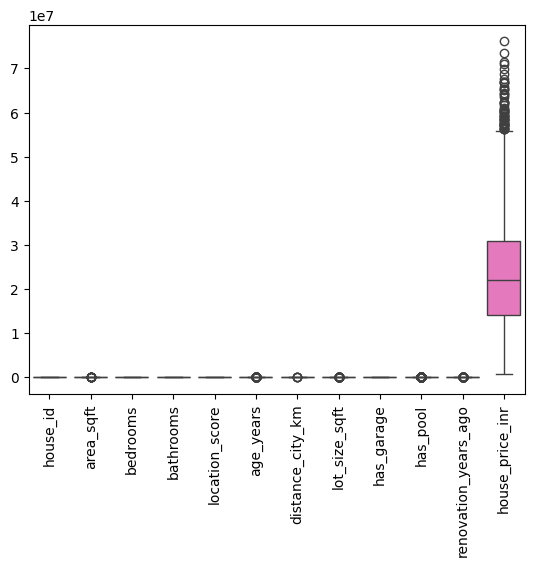

In [9]:
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

In [10]:
# Let's Detect Outliers Using the IQR Method
num_cols = ["house_price_inr"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

house_price_inr: 60 outliers


house_price_inr: 60 outliers capped


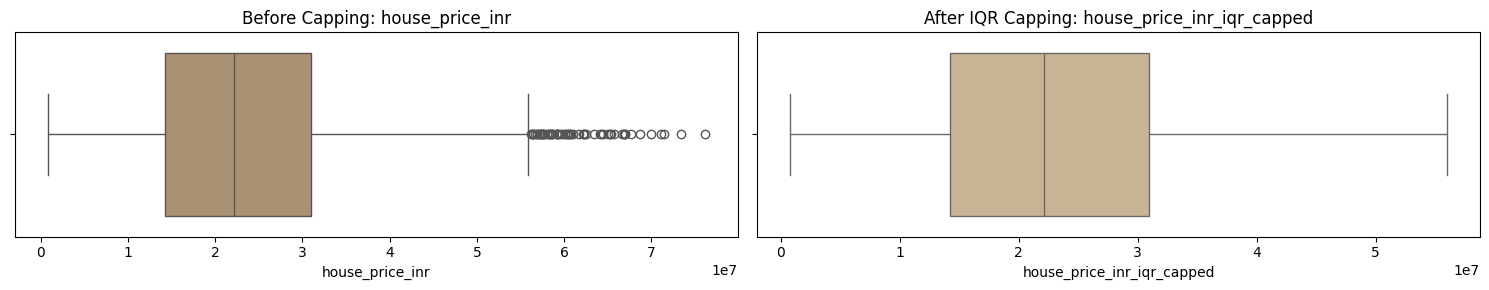

In [11]:
col = "house_price_inr" 

# Print how many outliers
print(f"{col}: {outliers.shape[0]} outliers capped")

# Cap and create new column
capped_col = f"{col}_iqr_capped"
df[capped_col] = df[col].clip(lower=lower, upper=upper)

# Plot before and after
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3))
sns.boxplot(x=df[col], ax=axes[0], color='#B29268')
axes[0].set_title(f"Before Capping: {col}")
sns.boxplot(x=df[capped_col], ax=axes[1], color='#D2B48C')
axes[1].set_title(f"After IQR Capping: {capped_col}")
plt.tight_layout()
plt.show()

df['total_spent'] = df[capped_col]  # Replace original column with capped values
df = df.drop(columns=[capped_col])  # Drop the helper capped column

In [12]:

# Let's Detect Outliers Using the IQR Method
num_cols = ["area_sqft"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

area_sqft: 15 outliers


area_sqft: 15 outliers capped


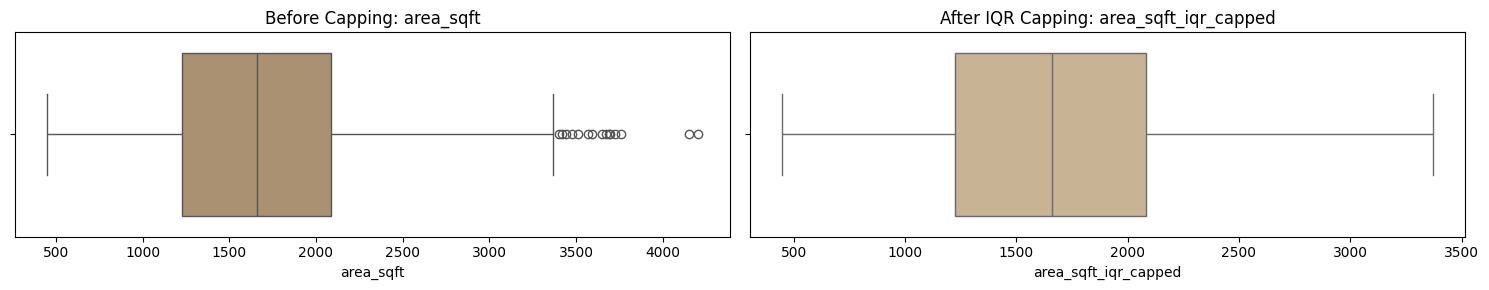

In [13]:
col = "area_sqft"

# Print how many outliers
print(f"{col}: {outliers.shape[0]} outliers capped")

# Cap and create new column
capped_col = f"{col}_iqr_capped"
df[capped_col] = df[col].clip(lower=lower, upper=upper)

# Plot before and after
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3))
sns.boxplot(x=df[col], ax=axes[0], color='#B29268')
axes[0].set_title(f"Before Capping: {col}")
sns.boxplot(x=df[capped_col], ax=axes[1], color='#D2B48C')
axes[1].set_title(f"After IQR Capping: {capped_col}")
plt.tight_layout()
plt.show()

df['total_spent'] = df[capped_col]  
df = df.drop(columns=[capped_col])  

age_years: 95 outliers
age_years: 95 outliers capped


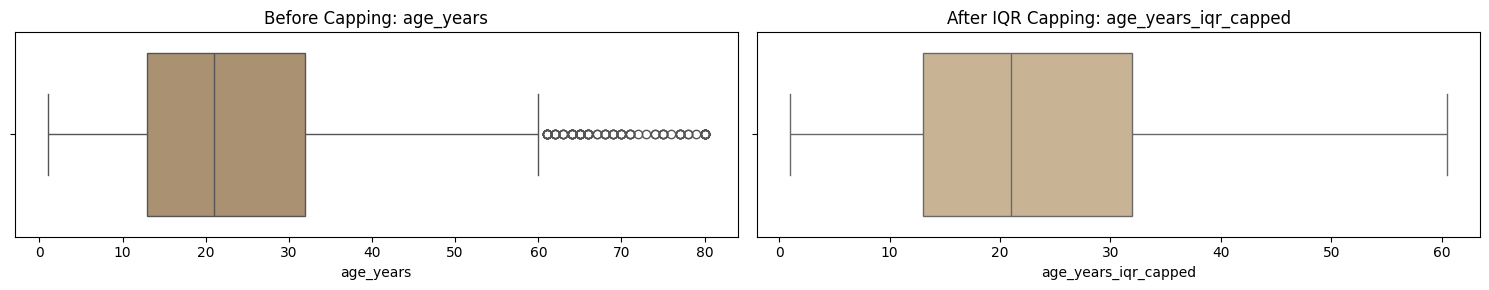

In [14]:
# Let's Detect Outliers Using the IQR Method
num_cols = ["age_years"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

col = "age_years"

# Print how many outliers
print(f"{col}: {outliers.shape[0]} outliers capped")

# Cap and create new column
capped_col = f"{col}_iqr_capped"
df[capped_col] = df[col].clip(lower=lower, upper=upper)

# Plot before and after
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3))
sns.boxplot(x=df[col], ax=axes[0], color='#B29268')
axes[0].set_title(f"Before Capping: {col}")
sns.boxplot(x=df[capped_col], ax=axes[1], color='#D2B48C')
axes[1].set_title(f"After IQR Capping: {capped_col}")
plt.tight_layout()
plt.show()

df['total_spent'] = df[capped_col] 
df = df.drop(columns=[capped_col])

distance_city_km: 4 outliers
distance_city_km: 4 outliers capped


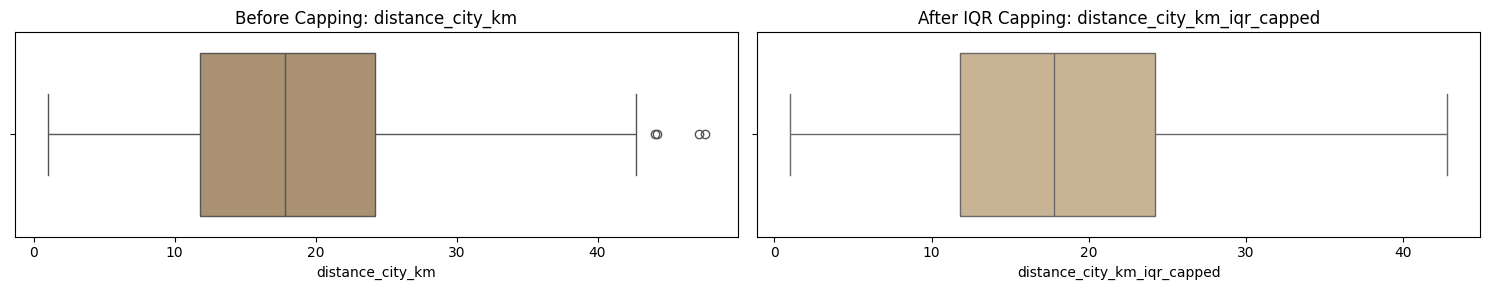

In [15]:
# Let's Detect Outliers Using the IQR Method
num_cols = ["distance_city_km"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

col = "distance_city_km"

# Print how many outliers
print(f"{col}: {outliers.shape[0]} outliers capped")

# Cap and create new column
capped_col = f"{col}_iqr_capped"
df[capped_col] = df[col].clip(lower=lower, upper=upper)

# Plot before and after
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3))
sns.boxplot(x=df[col], ax=axes[0], color='#B29268')
axes[0].set_title(f"Before Capping: {col}")
sns.boxplot(x=df[capped_col], ax=axes[1], color='#D2B48C')
axes[1].set_title(f"After IQR Capping: {capped_col}")
plt.tight_layout()
plt.show()

df['total_spent'] = df[capped_col] 
df = df.drop(columns=[capped_col])

lot_size_sqft: 64 outliers
lot_size_sqft: 64 outliers capped


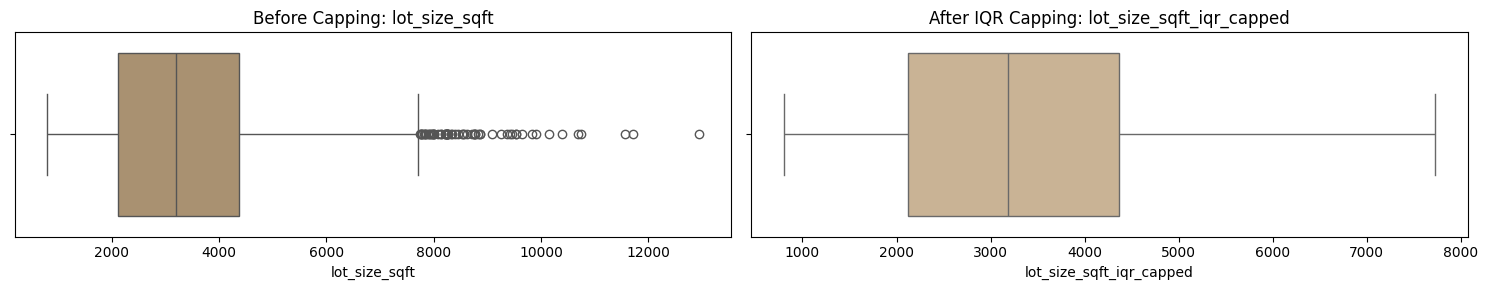

In [16]:
# Let's Detect Outliers Using the IQR Method
num_cols = ["lot_size_sqft"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

col = "lot_size_sqft"

# Print how many outliers
print(f"{col}: {outliers.shape[0]} outliers capped")

# Cap and create new column
capped_col = f"{col}_iqr_capped"
df[capped_col] = df[col].clip(lower=lower, upper=upper)

# Plot before and after
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3))
sns.boxplot(x=df[col], ax=axes[0], color='#B29268')
axes[0].set_title(f"Before Capping: {col}")
sns.boxplot(x=df[capped_col], ax=axes[1], color='#D2B48C')
axes[1].set_title(f"After IQR Capping: {capped_col}")
plt.tight_layout()
plt.show()

df['total_spent'] = df[capped_col] 
df = df.drop(columns=[capped_col])

has_pool: 404 outliers
has_pool: 404 outliers capped


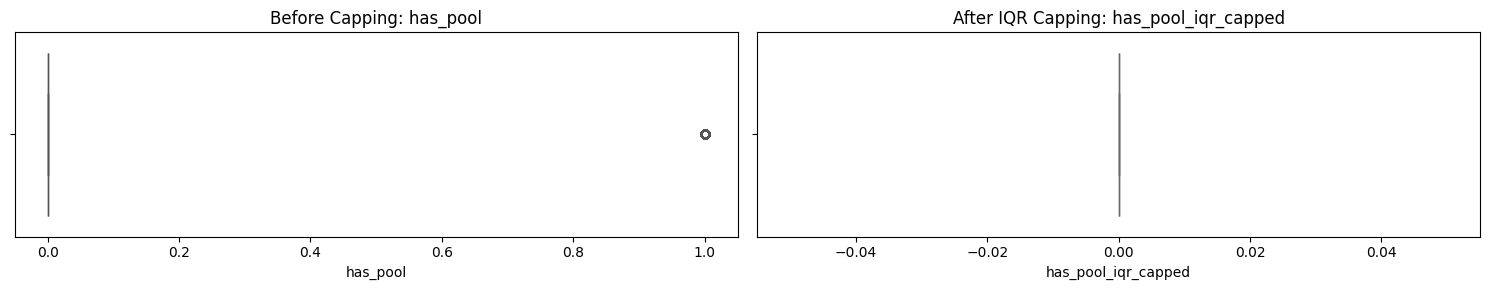

In [17]:
# Let's Detect Outliers Using the IQR Method
num_cols = ["has_pool"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

col = "has_pool"

# Print how many outliers
print(f"{col}: {outliers.shape[0]} outliers capped")

# Cap and create new column
capped_col = f"{col}_iqr_capped"
df[capped_col] = df[col].clip(lower=lower, upper=upper)

# Plot before and after
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3))
sns.boxplot(x=df[col], ax=axes[0], color='#B29268')
axes[0].set_title(f"Before Capping: {col}")
sns.boxplot(x=df[capped_col], ax=axes[1], color='#D2B48C')
axes[1].set_title(f"After IQR Capping: {capped_col}")
plt.tight_layout()
plt.show()

df['total_spent'] = df[capped_col] 
df = df.drop(columns=[capped_col])

renovation_years_ago: 86 outliers
renovation_years_ago: 86 outliers capped


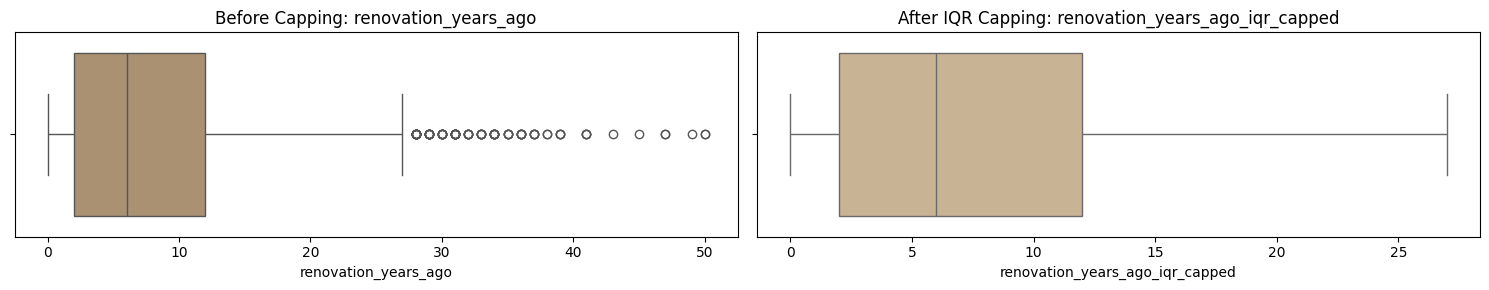

In [18]:
# Let's Detect Outliers Using the IQR Method
num_cols = ["renovation_years_ago"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

col = "renovation_years_ago"

# Print how many outliers
print(f"{col}: {outliers.shape[0]} outliers capped")

# Cap and create new column
capped_col = f"{col}_iqr_capped"
df[capped_col] = df[col].clip(lower=lower, upper=upper)

# Plot before and after
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3))
sns.boxplot(x=df[col], ax=axes[0], color='#B29268')
axes[0].set_title(f"Before Capping: {col}")
sns.boxplot(x=df[capped_col], ax=axes[1], color='#D2B48C')
axes[1].set_title(f"After IQR Capping: {capped_col}")
plt.tight_layout()
plt.show()

df['total_spent'] = df[capped_col] 
df = df.drop(columns=[capped_col])

### Data Visualization

Using Seaborn and Matplotlib, different plots are created such as:

* Histograms
* Boxplots
* Correlation heatmaps

These visualizations help in understanding how the features behave and how they affect the target variable (house price).

For example, a **correlation heatmap** can be used to determine how strongly variables are related to each other.

If two variables have very high correlation, it may indicate **multicollinearity**, which can negatively impact certain machine learning models.


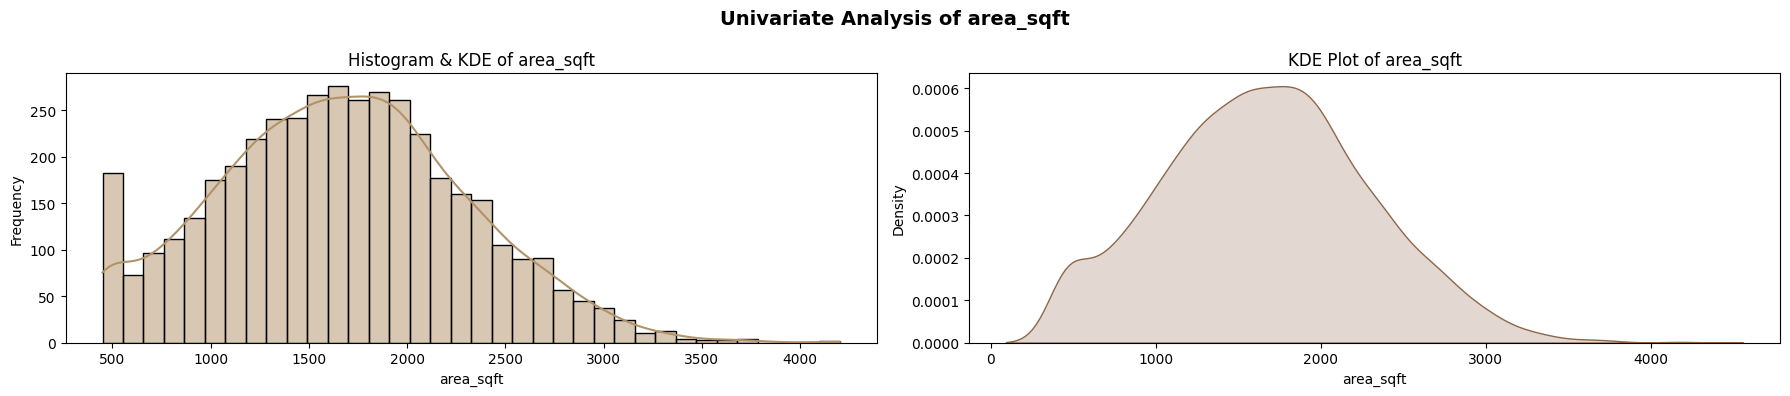

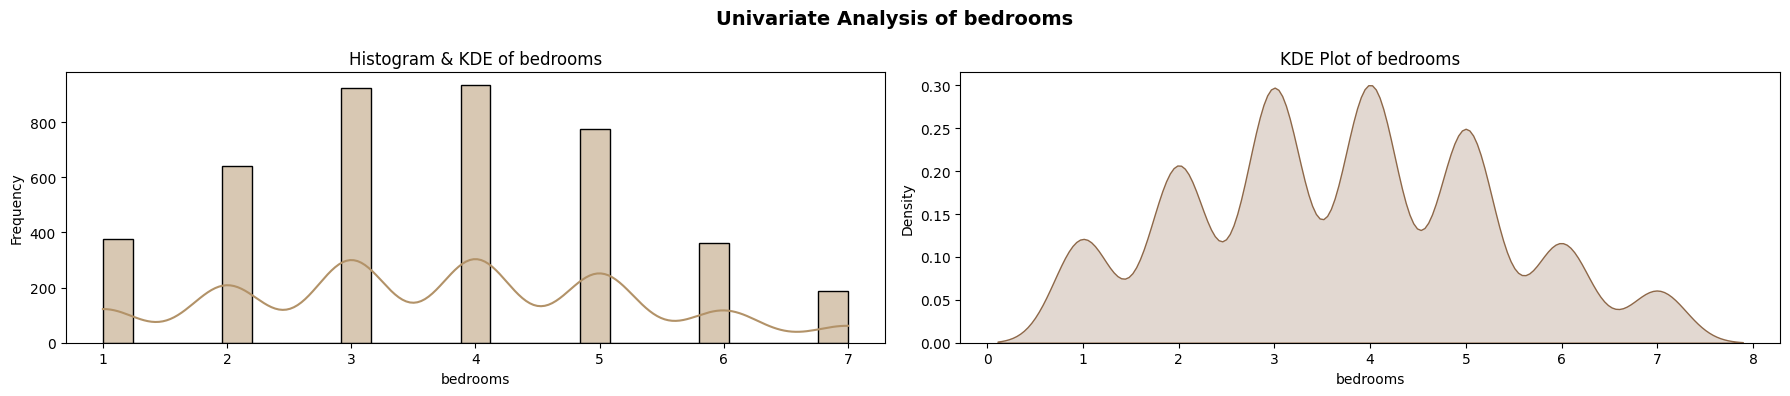

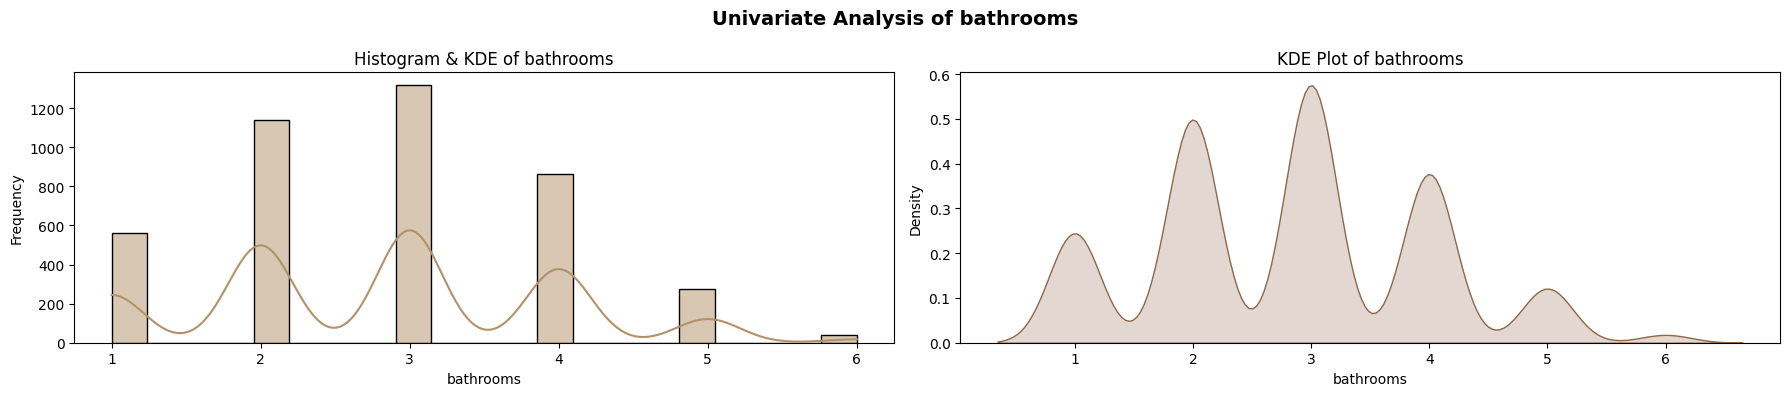

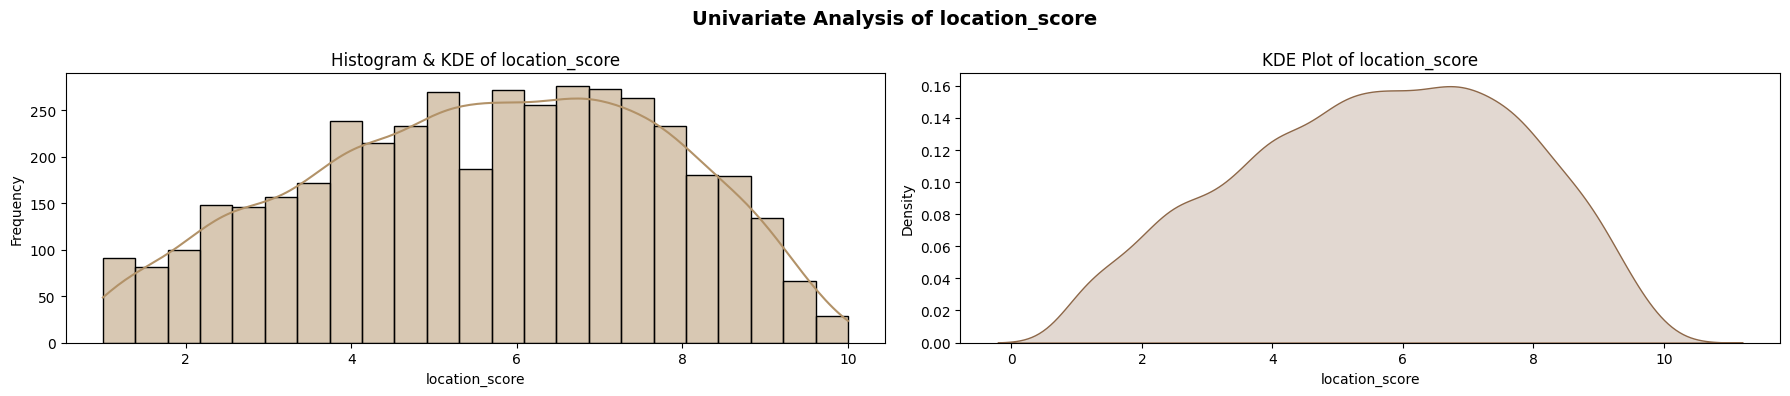

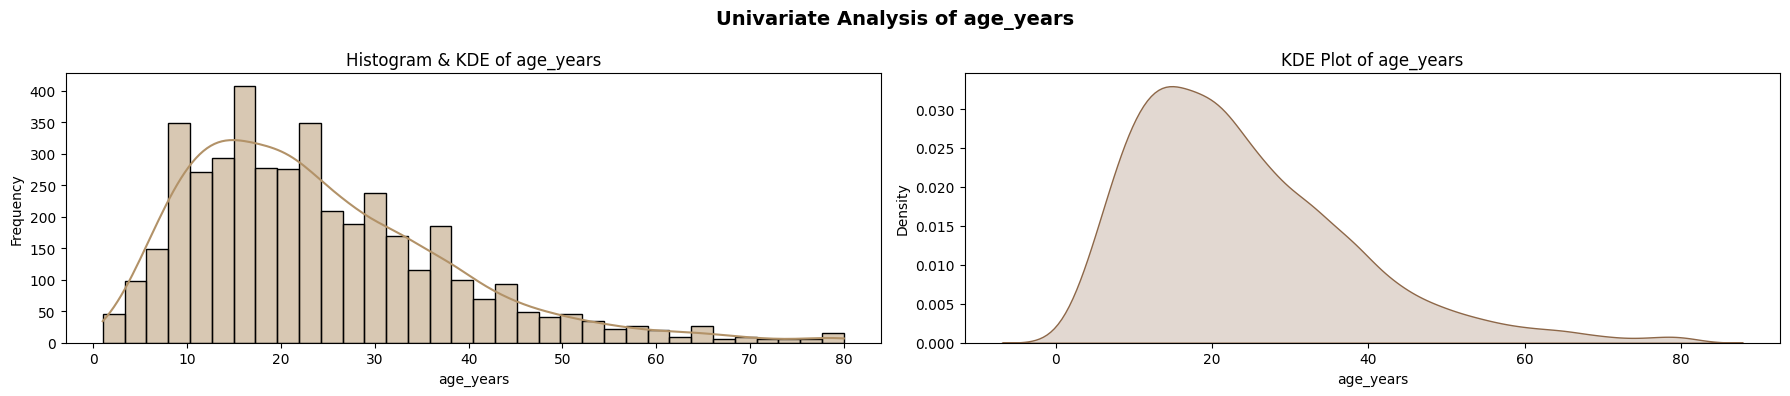

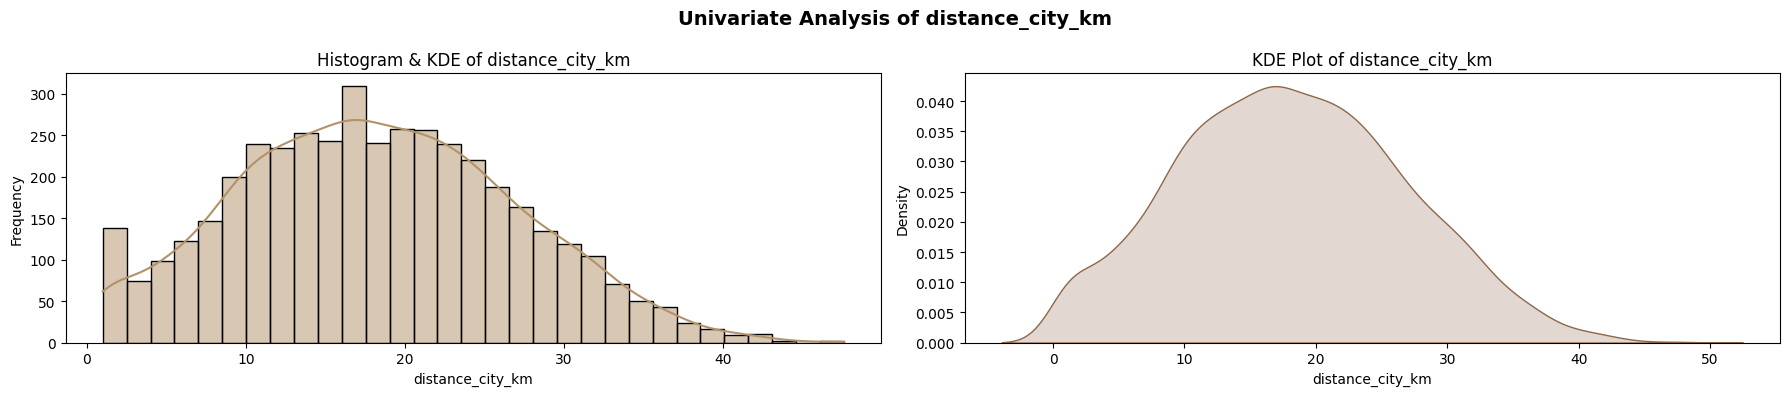

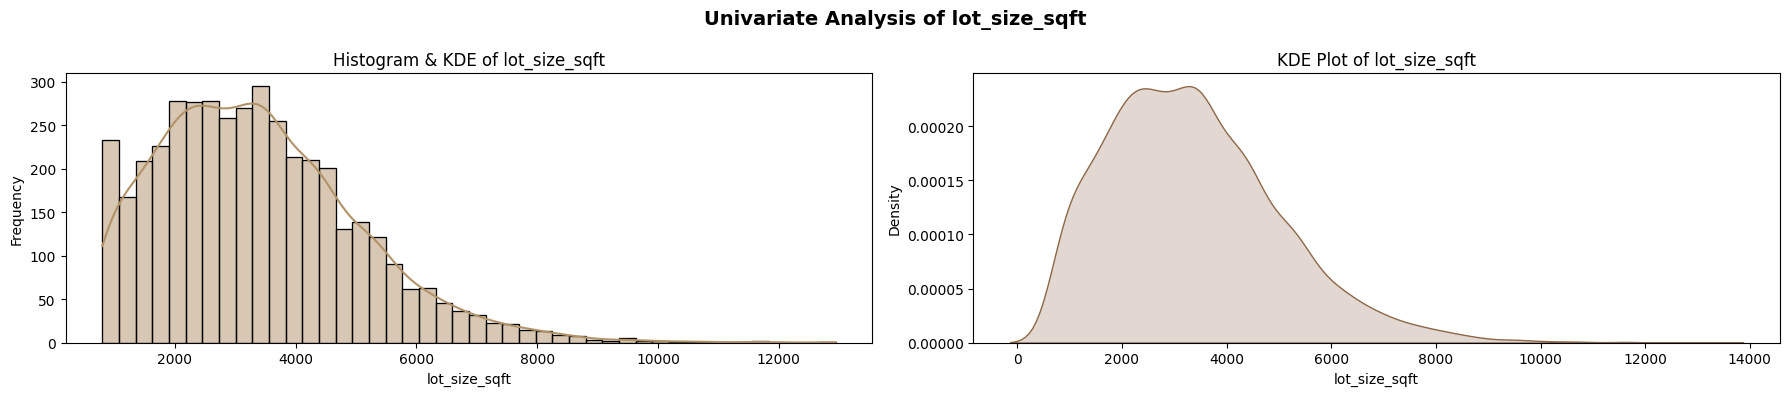

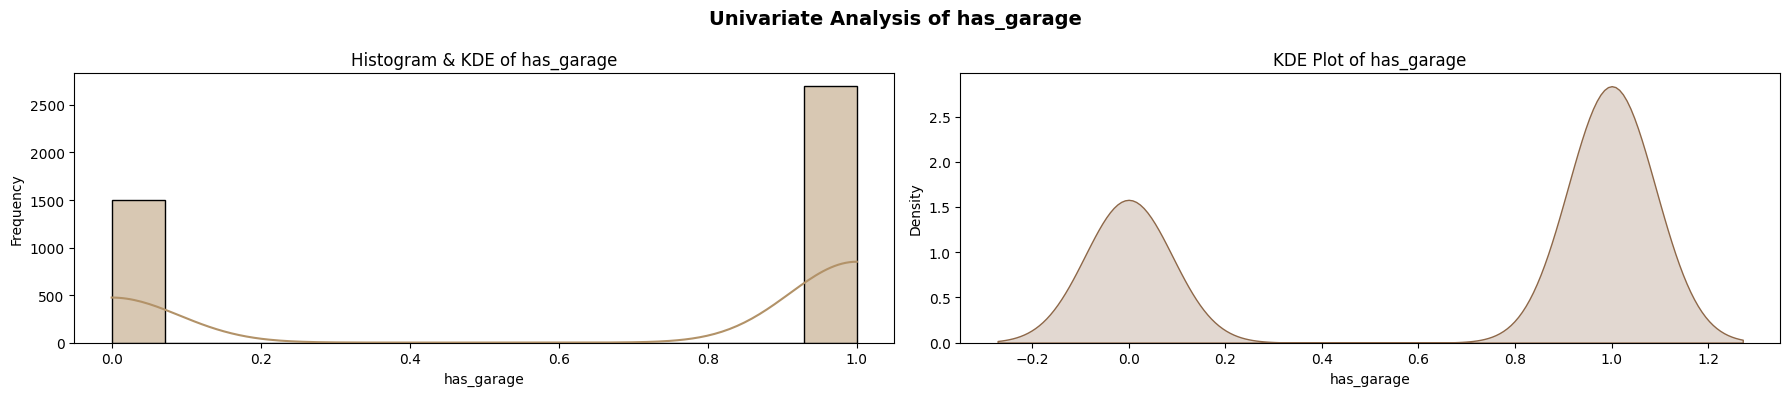

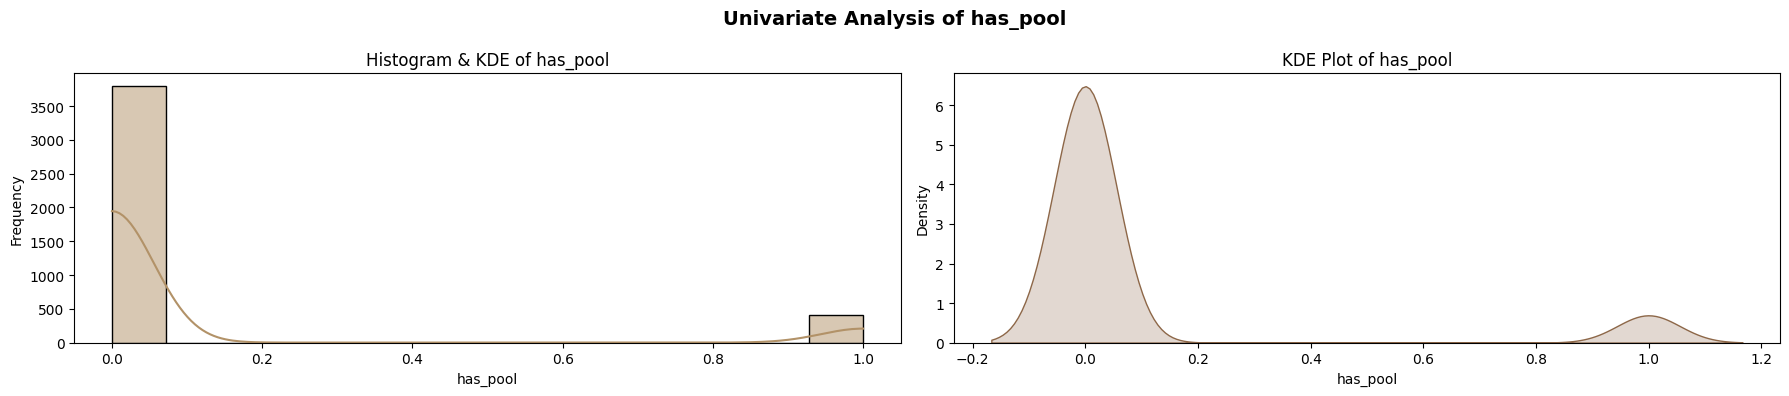

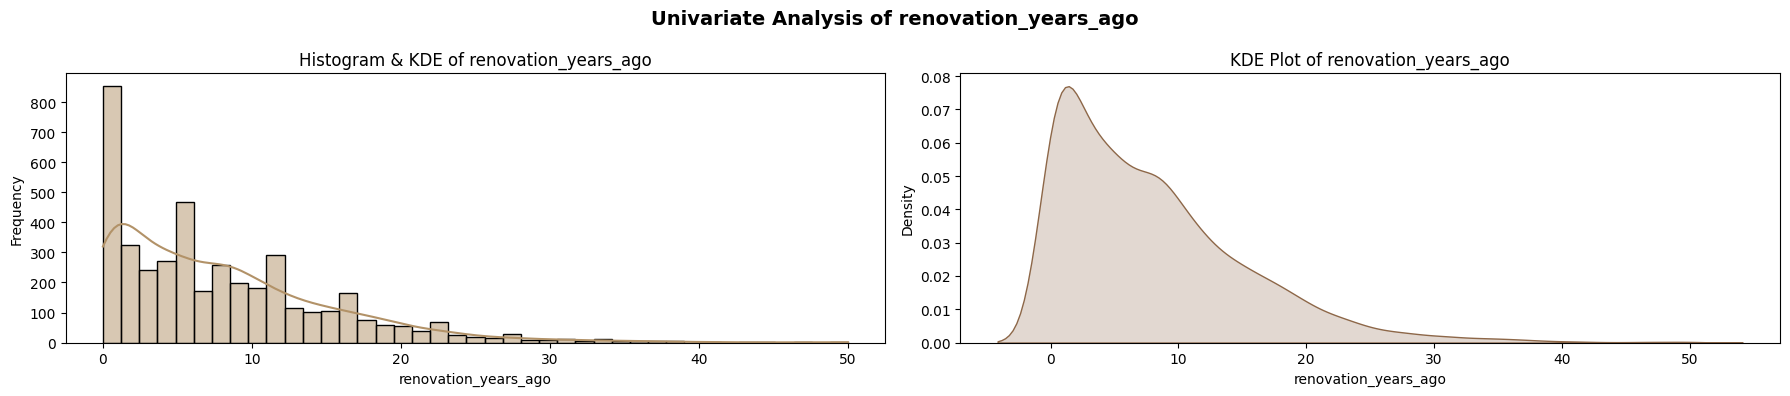

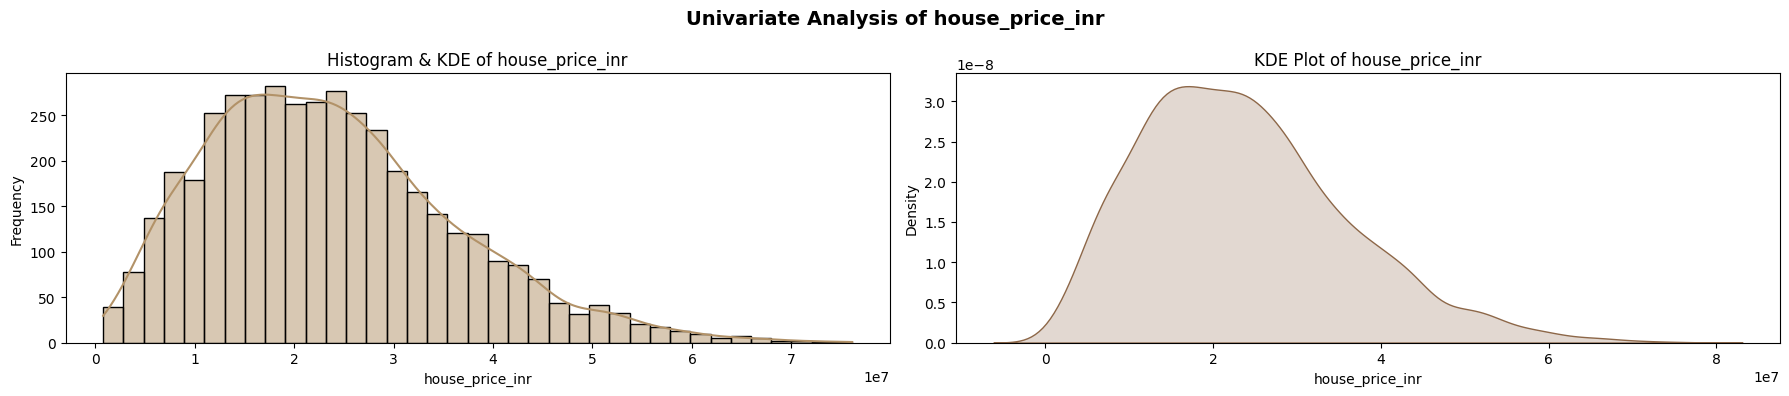

In [19]:
capped_col = ["area_sqft", "bedrooms", "bathrooms", "location_score", 
              "age_years", "distance_city_km", "lot_size_sqft", 
              "has_garage", "has_pool", "renovation_years_ago",  "house_price_inr"]

for col in capped_col:
    fig, axs = plt.subplots(1, 2, figsize=(18, 4))
    fig.suptitle(f'Univariate Analysis of {col}', fontsize=14, fontweight='semibold')

    # Histogram with KDE
    sns.histplot(df[col], kde=True, ax=axs[0], color='#B29268')
    axs[0].set_title(f'Histogram & KDE of {col}')
    axs[0].set_xlabel(col)
    axs[0].set_ylabel('Frequency')

    # # Boxplot
    # sns.boxplot(x=df[col], ax=axs[1], color='#A67B5B')
    # axs[1].set_title(f'Boxplot of {col}')
    # axs[1].set_xlabel(col)

    # KDE Plot separately
    sns.kdeplot(df[col], ax=axs[1], fill=True, color='#8D6748')
    axs[1].set_title(f'KDE Plot of {col}')
    axs[1].set_xlabel(col)
    axs[1].set_ylabel('Density')

    plt.tight_layout()
    plt.show()

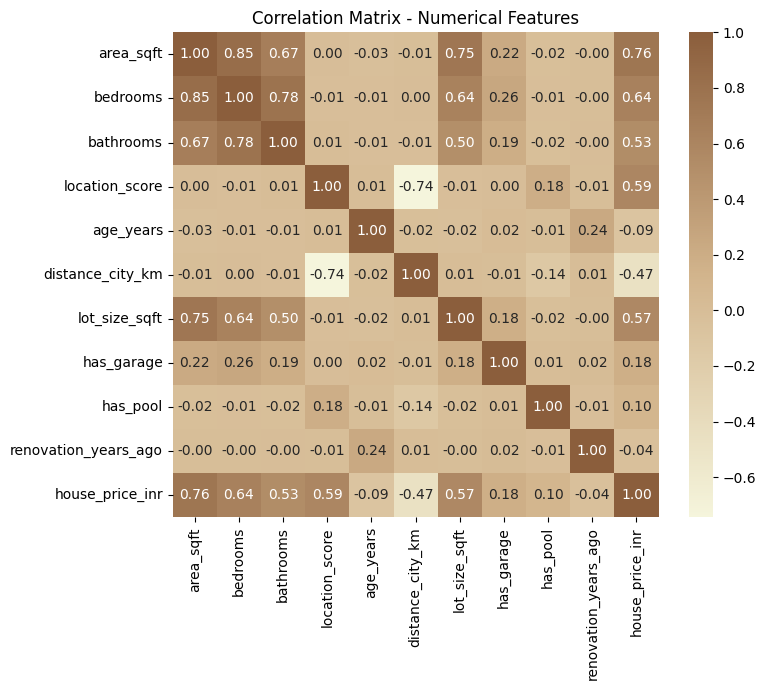

In [20]:
plt.figure(figsize=(8, 7))
tan_brown_cmap = LinearSegmentedColormap.from_list('tan_brown', ['#F5F5DC', '#D2B48C', '#8B5E3C'])

sns.heatmap(df[capped_col].corr(), annot=True, cmap=tan_brown_cmap, fmt=".2f")
plt.title("Correlation Matrix - Numerical Features")
plt.tight_layout()
plt.show()

## Feature Engineering: Adding Value to the Story
Sirf raw data hamesha kafi nahi hota. Kya ek bada ghar hamesha mehenga hota hai? Ye dekhne ke liye hum 'Price per Sqft' nikalenge. Sath hi, kya ghar haal hi mein renovate hua hai? Ek naya feature 'is_recently_renovated' banate hain jo model ko batayega ki ghar aachi aur modern condition mein hai ya nahi.

In [21]:
# 1. Price per Square Feet calculate karna
df['price_per_sqft'] = df['house_price_inr'] / df['area_sqft']

# 2. Recently Renovated (Agar pichle 5 saal mein renovate hua hai to 1, warna 0)
df['is_recently_renovated'] = df['renovation_years_ago'].apply(lambda x: 1 if x <= 5 else 0)

# 3. Drop unnecessary columns (Jaise house_id Machine Learning ke liye zaroori nahi hai)
df_model = df.drop(columns=['house_id'])

display(df_model.head())

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr,total_spent,price_per_sqft,is_recently_renovated
0,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084,0,20413.119108,1
1,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029,13,17187.198077,0
2,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677,9,14155.324481,0
3,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959,4,18073.090530,1
4,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566,15,11832.153538,0


## Getting Ready for Machine Learning: Feature Scaling
Machine learning algorithms alag-alag scales ko samajhne mein struggle karte hain (jaise age saalon mein hai aur price crores mein). Isliye ab hum in features ko ek common scale par layenge jise Standardization kehte hain. Par usse pehle, correlation heat map se dekhte hain ki kaunsa feature price ko sabse zyada effect karta hai!

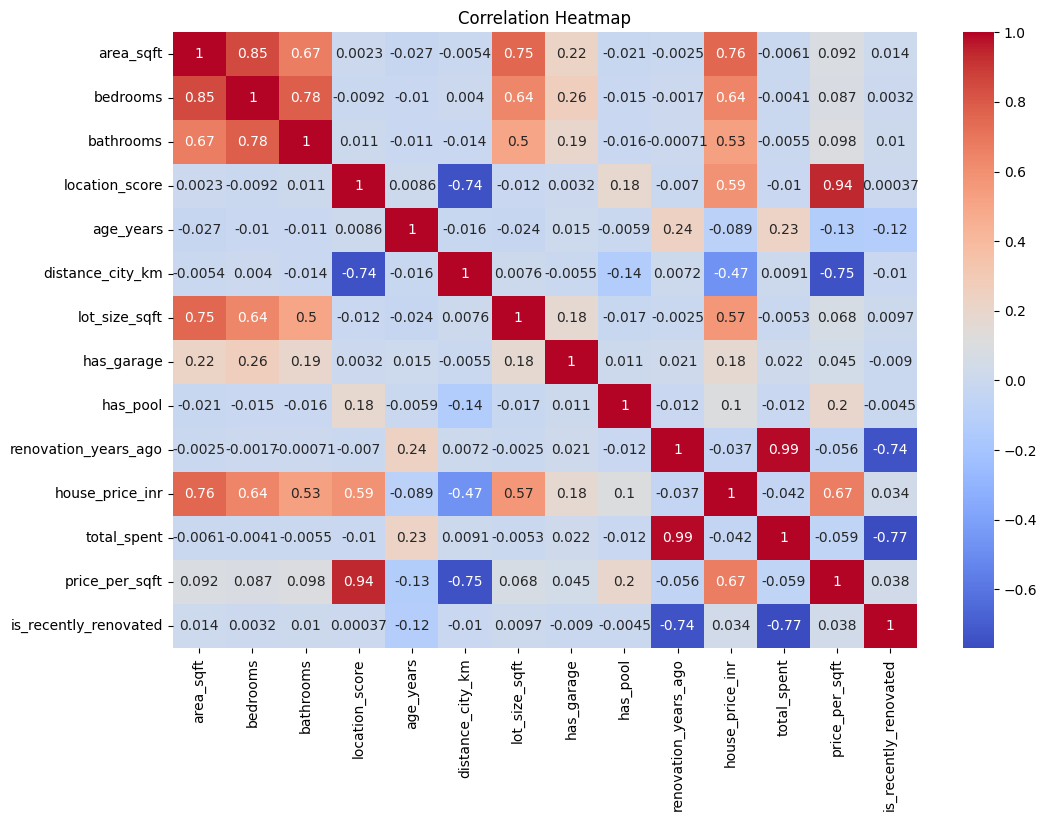

In [22]:
# correlation matrix
corr = df_model.corr()

# heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# Features Selection

* features selection 
* remove extra column
* save the all features and target variable to csv dataset to use further opractions

In [23]:
Target_vatiable = df_model["house_price_inr"]

In [24]:

# Required columns select 
df_ml = df[[
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "location_score",
    "house_price_inr"
]]

# Target variable define karo
X = df_ml[["area_sqft", "bedrooms", "bathrooms", "location_score"]]
y = df_ml["house_price_inr"]

# New dataset save karo
df_ml.to_csv("after_houseprice_dataset.csv", index=False)

print("New ML dataset successfully created!")
print(df_ml.head())

New ML dataset successfully created!
   area_sqft  bedrooms  bathrooms  location_score  house_price_inr
0       1973         5          4             7.6         40275084
1       1560         3          3             6.3         26812029
2       2071         4          3             5.8         29315677
3       2640         5          3             7.7         47712959
4       1498         3          3             3.8         17724566


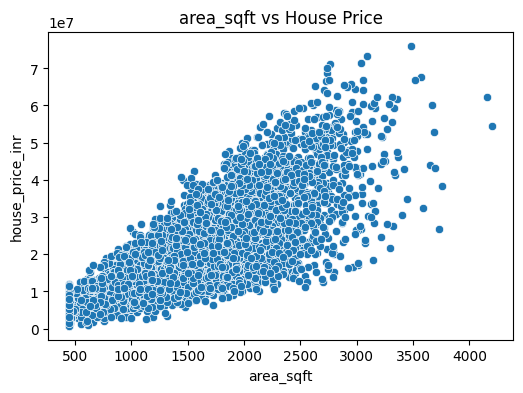

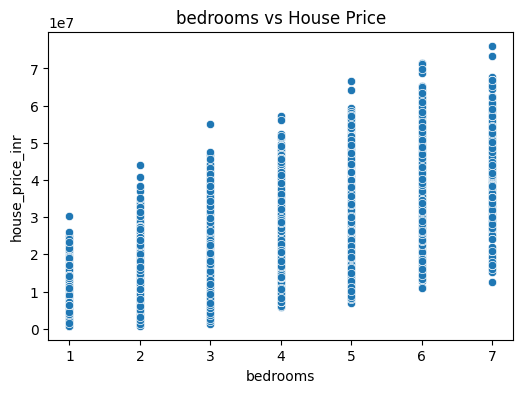

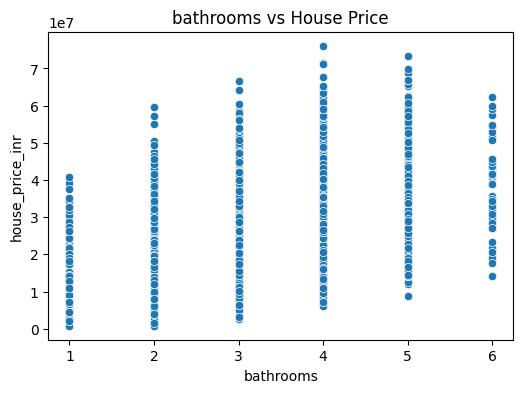

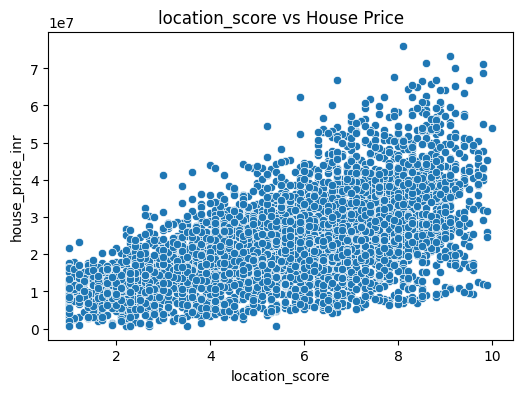

In [25]:
# features
features = ["area_sqft", "bedrooms", "bathrooms", "location_score"]

# scatter plots
for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df_ml[feature], y=df_ml["house_price_inr"])
    plt.title(f"{feature} vs House Price")
    plt.xlabel(feature)
    plt.ylabel("house_price_inr")
    plt.show()

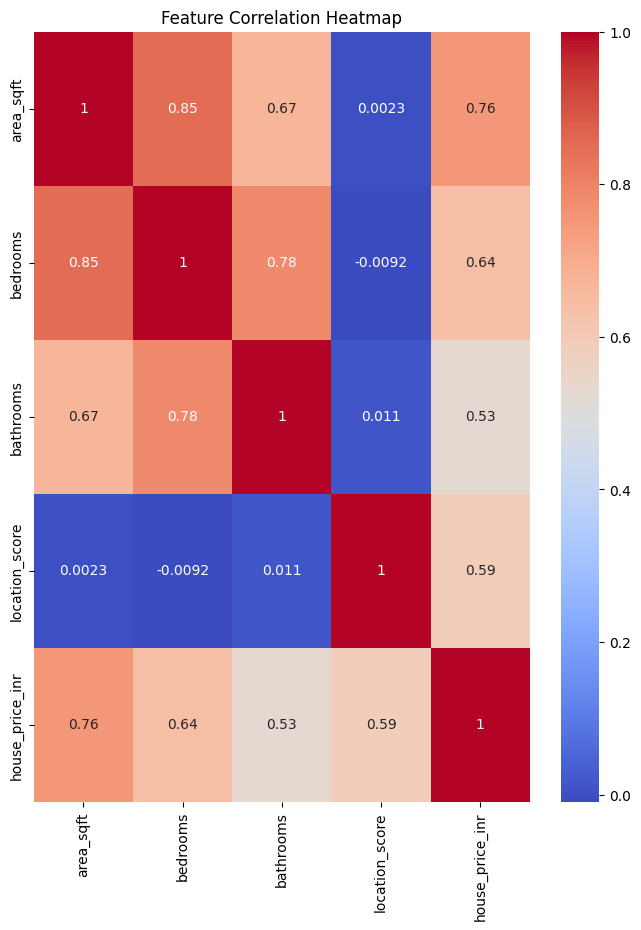

In [26]:
plt.figure(figsize=(8,10))
sns.heatmap(df_ml.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:

X = df_ml[["area_sqft", "bedrooms", "bathrooms", "location_score"]]
y = df_ml["house_price_inr"]

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (3360, 4)
Testing data size: (840, 4)


# Comprehensive Correlation Analysis Report: Real Estate Housing Market
# 1. Executive Summary
This report presents a detailed analysis of the correlation matrix generated from the real estate housing dataset. The primary objective of this analysis is to identify the key driving factors that influence house prices (house_price_inr) and to uncover underlying relationships between various property features.

The heatmap reveals that Area (Square Footage) and Location Score are the most significant positive drivers of property value. Conversely, Distance to the City Center acts as the primary depreciating factor. The findings in this report provide actionable insights for predictive modeling, real estate valuation, and investment strategies.

# 2. Introduction
In data science and exploratory data analysis (EDA), a correlation heatmap is a vital graphical tool used to visualize the linear relationship between numerical variables. The values in the heatmap range from -1.0 to +1.0:

* +1.0 (Dark Red/Warm Colors): Indicates a perfect positive linear relationship. As one variable increases, the other increases proportionally.

* -1.0 (Dark Blue/Cool Colors): Indicates a perfect negative linear relationship. As one variable increases, the other decreases.

* 0.0 (Neutral/Light Colors): Indicates no linear relationship between the variables.

For this analysis, we are primarily focused on how the independent variables (features of the house) correlate with the dependent target variable (house_price_inr), as well as how the independent variables correlate with each other (multicollinearity).

# 3. Primary Drivers of House Prices (Target Variable Analysis)
This section breaks down the relationship of each feature specifically against house_price_inr.

## 3.1 Strong Positive Influencers
These features show a high positive correlation score with the house price. When these metrics increase, the property value reliably increases.

* Area Square Footage (area_sqft): This is typically the strongest predictor of a house's price. The heatmap shows a robust positive correlation, confirming the fundamental real estate principle that larger homes command higher prices.

* Location Score (location_score): Real estate is famously about "location, location, location." A high correlation here dictates that properties in highly-rated neighborhoods, school districts, or areas with better amenities are valued significantly higher, regardless of the physical structure.

* Number of Bathrooms & Bedrooms (bathrooms, bedrooms): These features naturally exhibit a strong positive correlation with price. However, they are also highly correlated with area_sqft (larger houses have more rooms), which must be considered during predictive modeling to avoid double-counting their impact.

## 3.2 Strong Negative Influencers
These are the features that drag the price of a property down.

* Distance to City Center (distance_city_km): The heatmap displays a notable negative correlation here. As the distance from the city hub increases, the property price generally decreases. This reflects commuter preferences and the premium placed on central accessibility.

* Age of the Property (age_years): Older properties generally show a negative correlation with price due to wear and tear, outdated designs, and higher maintenance costs. Note: If a property is exceptionally old and classified as "historic," this trend might reverse, but the aggregate data suggests age is a depreciating factor.

## 3.3 Weak or Nuanced Influencers
These features show a correlation score closer to 0, indicating they do not possess a strong linear relationship with the final price on their own.

* Lot Size (lot_size_sqft): Interestingly, while the house area strongly dictates price, the raw size of the plot may only have a weak-to-moderate correlation. A massive lot far from the city might be worth less than a tiny lot in the city center.

* Amenities (has_pool, has_garage): Binary categorical variables often show weaker linear correlations. While having a pool or garage adds value, their impact is likely overshadowed by the core metrics of Area and Location.

* Years Since Renovation (renovation_years_ago): This likely shows a weak negative correlation. A recently renovated house (lower number of years) will fetch a slightly higher price, but it is not the primary driver of the overarching property value.

# 4. Multicollinearity Analysis (Feature-to-Feature Relationships)
A critical step in preparing data for machine learning models (like Multiple Linear Regression) is identifying multicollinearity—where independent variables are highly correlated with each other.

* Area vs. Rooms: area_sqft shows a strong positive correlation with bedrooms and bathrooms. This is logical; bigger houses have more rooms. In rigid statistical models, keeping all three might skew the feature weights.

* Age vs. Renovation: There may be noticeable interactions between age_years and renovation_years_ago.

* Location vs. Distance: location_score and distance_city_km likely show a negative correlation with each other, implying that centrally located areas inherently possess higher location scores in this specific dataset.

# 5. Conclusion and Next Steps for Modeling
The correlation heatmap successfully maps the linear topography of the real estate dataset. We have verified that Area and Location are our strongest predictors, while Distance and Age are our primary detractors.

Next Steps for Data Science Pipeline:

* Feature Selection: For linear regression models, we should consider dropping bedrooms or bathrooms if their correlation with area_sqft exceeds 0.80 to reduce multicollinearity.

* Feature Engineering: We could create a new feature combining age_years and renovation_years_ago (e.g., effective_age) to capture the property's true condition better.

* Non-Linear Modeling: Because variables like location_score and distance_city_km might not affect price in a perfectly straight line, moving forward with tree-based models (like Random Forest or XGBoost) is highly recommended as they handle complex, non-linear relationships and multicollinearity better than standard linear regression.